In [1]:
import os
import pickle
import pandas as pd

In [2]:
# Define the directory containing the CSV files
shap_directory = "/home/guillen/Conference Paper SHAP Maciej actualizado/Diabetes/shap"

parquet_directory = "/home/guillen/Conference Paper SHAP Maciej actualizado/Diabetes/shap"

In [3]:
featuresList = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

#read .csv files
# Get all files starting with "shap_list_ir" and ending with ".csv"
csv_files = [f for f in os.listdir(shap_directory) if f.startswith("shap_list_ir") and f.endswith(".csv")]

%%time
#read parquet files

# Get all files starting with "shap_list_ir" and ending with ".parquet"
parquet_files = [f for f in os.listdir(shap_directory) if f.startswith("shap_list_ir") and f.endswith(".parquet")]

# Iterate through parquet files and process them
for file in parquet_files:
    file_path = os.path.join(shap_directory, file)
    # Read the parquet file into a DataFrame
    df = pd.read_parquet(file_path)
    # Process the DataFrame (example: print first 5 rows)
    print(f"Processing file: {file}")
    #print(df.head())

%%time
# Save as parquet

# Loop through the files and save each as a Parquet file
for csv_file in csv_files:
    # Full path to the CSV file
    csv_path = os.path.join(shap_directory, csv_file)
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(csv_path)
    
    # Construct the output Parquet file path
    parquet_file = os.path.join(parquet_directory, f"{os.path.splitext(csv_file)[0]}.parquet")
    
    # Save the DataFrame as a Parquet file
    df.to_parquet(parquet_file, index=False)
    

# .pkl files version

# Get all files in the directory starting with "shap_list_ir" and ending with ".pkl"
pkl_files = [f for f in os.listdir(shap_directory) if f.startswith("shap_list_ir") and f.endswith(".pkl")]

# Load each file into a variable with the same name as the file
for pkl_file in pkl_files:
    variable_name = pkl_file.replace(".pkl", "")  # Remove .pkl to create the variable name
    file_path = os.path.join(shap_directory, pkl_file)  # Full path to the file
    
    # Load the .pkl file
    with open(file_path, 'rb') as f:
        globals()[variable_name] = pickle.load(f)


## Data preparation

### Selection of Shap values for true class

In [4]:
%%time
# Dictionary to store DataFrames temporarily by their base name (excluding class label)
dataframes = {}

# Get all files starting with "shap_list_ir" and ending with ".parquet"
parquet_files = [f for f in os.listdir(shap_directory) if f.startswith("xgb_shap_list_ir") and f.endswith(".parquet")]

# Load each file into a DataFrame, add 'shapClass' column
for file in parquet_files:
    # Determine the class value from the filename
    class_value = 0 if "_class0" in file else 1  # Extract class from filename
    
    # Base name without the class label and extension
    base_name = file.replace("_class0.parquet", "").replace("_class1.parquet", "")
    
    # Load the CSV file into a DataFrame and add 'shapClass' column
    file_path = os.path.join(shap_directory, file)
    df = pd.read_parquet(file_path)
    df['shapClass'] = class_value
    
    # Store the DataFrame in a dictionary under its base name
    if base_name not in dataframes:
        dataframes[base_name] = []
    dataframes[base_name].append(df)



# Define a list to store the names of the new DataFrames
subsetList = []

# Combine paired DataFrames and create new variables
for base_name, df_list in dataframes.items():
    if len(df_list) == 2:  # Ensure we have both class0 and class1 DataFrames
        combined_df = pd.concat(df_list, ignore_index=True)  # Combine the two DataFrames
        
        # Create a variable in the global namespace with the base_name
        globals()[base_name] = combined_df
        
        # Add the base_name to the subsetList
        subsetList.append(base_name)

# Print the list of new DataFrames
#print(f"Combined DataFrames created: {', '.join(subsetList)}")


CPU times: user 19.2 s, sys: 2.49 s, total: 21.7 s
Wall time: 5min 7s


In [5]:
# Replace values in Real_class and Predicted_class for each DataFrame in subsetList
for df_name in subsetList:
    df = globals()[df_name]  # Access the DataFrame by its name
    df['Real_class'] = df['Real_class'].replace({'NO': 0, 'SI': 1})
    df['Predicted_class'] = df['Predicted_class'].replace({'NO': 0, 'SI': 1})

/tmp/ipykernel_2222653/1657802143.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Real_class'] = df['Real_class'].replace({'NO': 0, 'SI': 1})
/tmp/ipykernel_2222653/1657802143.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Predicted_class'] = df['Predicted_class'].replace({'NO': 0, 'SI': 1})


In [6]:
# Filter rows where Predicted_class equals shapClass for each DataFrame in subsetList
for df_name in subsetList:
    df = globals()[df_name]  # Access the DataFrame by its name
    
    # Filter rows with matching Predicted_class and shapClass
    df_filtered = df.loc[df['Predicted_class'] == df['shapClass']]
       
    # Overwrite the original DataFrame with the filtered DataFrame
    globals()[df_name] = df_filtered

In [7]:
len(subsetList)

800

In [8]:
xgb_shap_list_ir_1_subset_10.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'PATIENT_ID', 'Real_class',
       'Predicted_class', 'Model_Output', 'shapClass'],
      dtype='object')

# Scoring calculation

## Order indicator

In [9]:
df_filtered.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'PATIENT_ID', 'Real_class',
       'Predicted_class', 'Model_Output', 'shapClass'],
      dtype='object')

In [10]:
%%time
# Define sorting preferences for each indicator
sort_order_mean = 'descending'    # Options: 'ascending' or 'descending'
sort_order_std = 'descending'
sort_order_sum = 'descending'

# Define the list of features (replace with actual feature names)
#featuresList = ['feature_0', 'feature_1', 'feature_2', ...]  # Add all your feature names here

# Dictionary to store sorted feature lists for each indicator
sorted_features = {}
sorted_values = {}
# Loop through each DataFrame in subsetList
for df_name in subsetList:
    df = globals()[df_name]  # Access the DataFrame by its name
    
    # Calculate absolute values of the features
    df_abs = df[featuresList].abs()
    
    # Calculate mean, std, and sum for each feature
    feature_mean = df_abs.mean()
    feature_std = df_abs.std()
    feature_sum = df_abs.sum()
    
    # Sort feature names based on each indicator
    sorted_mean = feature_mean.sort_values(ascending=(sort_order_mean == 'ascending')).index.tolist()
    sorted_std = feature_std.sort_values(ascending=(sort_order_std == 'ascending')).index.tolist()
    sorted_sum = feature_sum.sort_values(ascending=(sort_order_sum == 'ascending')).index.tolist()
    
    # Store the sorted lists in the dictionary
    sorted_features[df_name] = {
        'orderMean': sorted_mean,
        'orderStd': sorted_std,
        'orderSum': sorted_sum}
        
        # Store the sorted lists in the dictionary
    sorted_values[df_name] = {
        'shapMean': feature_mean,
        'shapStd': feature_std,
        'shapSum': feature_sum
    }

# # Print results
# for df_name, orders in sorted_features.items():
#     print(f"DataFrame: {df_name}")
#     print(f"  Features sorted by Mean: {orders['orderMean']}")
#     print(f"  Features sorted by Std:  {orders['orderStd']}")
#     print(f"  Features sorted by Sum:  {orders['orderSum']}")
#     print()  # Add spacing between DataFrames


CPU times: user 3.53 s, sys: 74.9 ms, total: 3.61 s
Wall time: 45.8 s


In [11]:
%%time
# Initialize an empty list to collect DataFrames
dfs = []

# Loop through the subsets in the dictionary
for key, value in sorted_values.items():
    
    # Convert the nested dictionary to a DataFrame
    df = pd.DataFrame(value)
    # Add the subset identifier as a new column
    df['subset'] = key
    
    imbalance_ratio = "_".join(key.split('_')[:-2])
    df['imbalance_ratio'] = imbalance_ratio
    # Append the DataFrame to the list
    dfs.append(df)

# Concatenate all DataFrames from the list into a single DataFrame
sorted_orderValuesScore = pd.concat(dfs, axis=0)

# Reset index to make it clean
sorted_orderValuesScore.reset_index(inplace=True)

CPU times: user 931 ms, sys: 25.3 ms, total: 956 ms
Wall time: 13.4 s


In [12]:
sorted_orderValuesScore

,index,shapMean,shapStd,shapSum,subset,imbalance_ratio
0,Pregnancies,0.365379,0.257954,186.343109,xgb_shap_list_ir_5_subset_85,xgb_shap_list_ir_5
1,Glucose,1.446910,1.016040,737.924011,xgb_shap_list_ir_5_subset_85,xgb_shap_list_ir_5
2,BloodPressure,0.303973,0.215165,155.026245,xgb_shap_list_ir_5_subset_85,xgb_shap_list_ir_5
3,SkinThickness,0.280523,0.232566,143.066895,xgb_shap_list_ir_5_subset_85,xgb_shap_list_ir_5
4,Insulin,0.173743,0.159083,88.608810,xgb_shap_list_ir_5_subset_85,xgb_shap_list_ir_5
...,...,...,...,...,...,...
6395,SkinThickness,0.224586,0.176673,114.538734,xgb_shap_list_ir_5_subset_101,xgb_shap_list_ir_5
6396,Insulin,0.255351,0.190541,130.228851,xgb_shap_list_ir_5_subset_101,xgb_shap_list_ir_5
6397,BMI,0.944439,0.753524,481.663849,xgb_shap_list_ir_5_subset_101,xgb_shap_list_ir_5
6398,DiabetesPedigreeFunction,0.621423,0.447852,316.925659,xgb_shap_list_ir_5_subset_101,xgb_shap_list_ir_5


In [13]:
%%time

# Flatten the sorted_features dictionary into rows for a DataFrame
rows = []
for df_name, orders in sorted_features.items():
    for indicator, sorted_list in orders.items():
        # Extract the imbalance ratio (prefix before "_subset")
        imbalance_ratio = "_".join(df_name.split('_')[:-2]) 
        
        
        rows.append({
            'imbalanceRatio': imbalance_ratio,
            'Subset': df_name,
            'Indicator': indicator,
            'Sorted_Features': sorted_list
        })

# Convert the list of rows into a DataFrame
sorted_orderScore = pd.DataFrame(rows)

CPU times: user 13.2 ms, sys: 138 μs, total: 13.4 ms
Wall time: 32.2 ms


In [14]:
sorted_orderScore

,imbalanceRatio,Subset,Indicator,Sorted_Features
0,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,orderMean,"[Glucose, BMI, DiabetesPedigreeFunction, Age, ..."
1,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,orderStd,"[Glucose, BMI, DiabetesPedigreeFunction, Age, ..."
2,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,orderSum,"[Glucose, BMI, DiabetesPedigreeFunction, Age, ..."
3,xgb_shap_list_ir_2,xgb_shap_list_ir_2_subset_79,orderMean,"[Glucose, BMI, Age, Pregnancies, DiabetesPedig..."
4,xgb_shap_list_ir_2,xgb_shap_list_ir_2_subset_79,orderStd,"[Glucose, BMI, Age, DiabetesPedigreeFunction, ..."
...,...,...,...,...
2395,xgb_shap_list_ir_2,xgb_shap_list_ir_2_subset_74,orderStd,"[BMI, Glucose, Age, DiabetesPedigreeFunction, ..."
2396,xgb_shap_list_ir_2,xgb_shap_list_ir_2_subset_74,orderSum,"[Glucose, BMI, Age, DiabetesPedigreeFunction, ..."
2397,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,orderMean,"[Glucose, Age, BMI, DiabetesPedigreeFunction, ..."
2398,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,orderStd,"[Glucose, BMI, Age, DiabetesPedigreeFunction, ..."


In [15]:
sorted_orderValuesScore

,index,shapMean,shapStd,shapSum,subset,imbalance_ratio
0,Pregnancies,0.365379,0.257954,186.343109,xgb_shap_list_ir_5_subset_85,xgb_shap_list_ir_5
1,Glucose,1.446910,1.016040,737.924011,xgb_shap_list_ir_5_subset_85,xgb_shap_list_ir_5
2,BloodPressure,0.303973,0.215165,155.026245,xgb_shap_list_ir_5_subset_85,xgb_shap_list_ir_5
3,SkinThickness,0.280523,0.232566,143.066895,xgb_shap_list_ir_5_subset_85,xgb_shap_list_ir_5
4,Insulin,0.173743,0.159083,88.608810,xgb_shap_list_ir_5_subset_85,xgb_shap_list_ir_5
...,...,...,...,...,...,...
6395,SkinThickness,0.224586,0.176673,114.538734,xgb_shap_list_ir_5_subset_101,xgb_shap_list_ir_5
6396,Insulin,0.255351,0.190541,130.228851,xgb_shap_list_ir_5_subset_101,xgb_shap_list_ir_5
6397,BMI,0.944439,0.753524,481.663849,xgb_shap_list_ir_5_subset_101,xgb_shap_list_ir_5
6398,DiabetesPedigreeFunction,0.621423,0.447852,316.925659,xgb_shap_list_ir_5_subset_101,xgb_shap_list_ir_5


In [16]:
sorted_orderValuesScore.to_csv("sorted_orderValuesScore_xgb.csv")

In [17]:
sorted_orderScore.to_csv("shap_orderScore_xgb.csv")

***
***
# in progress/trash

## Distance indicator

%%time
import matplotlib.pyplot as plt

# Assuming 'shap_list_ir_1_subset_1' and 'featuresList' are already defined
df = shap_list_ir_1_subset_248  # Access the DataFrame

# Create histograms for each feature
for feature in featuresList:
    plt.figure(figsize=(6, 4))  # Set figure size
    plt.hist(df[feature], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram for {feature}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    
    # Save the histogram as a PNG file in the specified folder
    filename = os.path.join(output_folder, f"Histogram_for_{feature.replace(' ', '_')}.png")  # Replace spaces with underscores for filenames
    plt.savefig(filename, dpi=300, bbox_inches='tight')

## max density

In [18]:
%%time
import numpy as np
import pandas as pd

# List to store the results
histogram_results = []

# Loop through each DataFrame in subsetList
for df_name in subsetList:
    df = globals()[df_name]  # Access the DataFrame by its name
    
    # Loop through each feature in featuresList
    for feature in featuresList:
        # Calculate histogram data (20 bins, default behavior)
        values, bins = np.histogram(df[feature].dropna(), bins=20)
        
        # Sort frequencies to get the top 3 points
        top_indices = np.argsort(values)[-3:][::-1]  # Get indices of 3 highest frequencies in descending order
        
        # Calculate the values corresponding to the highest frequencies (bin centers)
        bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers
        top_frequencies = [bin_centers[i] for i in top_indices]
        
        # Append results: subset name and top 3 frequency points
        histogram_results.append({
            'Subset': f'{df_name}_{feature}',
            'freq1': top_frequencies[0],
            'freq2': top_frequencies[1],
            'freq3': top_frequencies[2]
        })

# Create a DataFrame from the results
maxDensityValues = pd.DataFrame(histogram_results)

# Display the resulting DataFrame
print(maxDensityValues)


                                                 Subset     freq1     freq2  \
0              xgb_shap_list_ir_5_subset_85_Pregnancies  0.269109  0.158290   
1                  xgb_shap_list_ir_5_subset_85_Glucose  0.445382  0.774194   
2            xgb_shap_list_ir_5_subset_85_BloodPressure  0.238686  0.345052   
3            xgb_shap_list_ir_5_subset_85_SkinThickness  0.222709  0.132807   
4                  xgb_shap_list_ir_5_subset_85_Insulin  0.093042  0.203494   
...                                                 ...       ...       ...   
6395        xgb_shap_list_ir_5_subset_101_SkinThickness  0.046969  0.137233   
6396              xgb_shap_list_ir_5_subset_101_Insulin -0.120562 -0.218140   
6397                  xgb_shap_list_ir_5_subset_101_BMI  0.288822  0.034849   
6398  xgb_shap_list_ir_5_subset_101_DiabetesPedigree...  0.807915  0.613667   
6399                  xgb_shap_list_ir_5_subset_101_Age  1.177993 -0.401637   

         freq3  
0     0.379927  
1     1.103006  


In [19]:
%%time
import numpy as np
import pandas as pd

# Define the number of bins as a variable
num_bins = 20  # You can change this value as needed

# List to store the results
histogram_results = []

# Loop through each DataFrame in subsetList
for df_name in subsetList:
    df = globals()[df_name]  # Access the DataFrame by its name
    
    # Loop through each feature in featuresList
    for feature in featuresList:
        # Calculate histogram data
        values, bins = np.histogram(df[feature].dropna(), bins=num_bins)
        
        # Sort frequencies to get the top 3 points
        top_indices = np.argsort(values)[-3:][::-1]  # Get indices of 3 highest frequencies in descending order
        
        # Calculate the values corresponding to the highest frequencies (bin centers)
        bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers
        top_frequencies = [bin_centers[i] for i in top_indices]
        
        # Extract the imbalance ratio (prefix before "_subset")
        imbalance_ratio = "_".join(df_name.split('_')[:-2]) 
        
        # Append results: subset name, top 3 frequency points, imbalance ratio, and feature name
        histogram_results.append({
            'imbalanceRatio': imbalance_ratio,
            'Subset': df_name,
            'feature': feature, 
            'Indicator': f'localMax_{feature}',             
            'freq1': top_frequencies[0],
            'freq2': top_frequencies[1],
            'freq3': top_frequencies[2]         
        })

# Create a DataFrame from the results
maxDensityValues = pd.DataFrame(histogram_results)

print("Wrong calculation of freq2 and freq3, ther are next 2 maxes, not next 2 density points, freq1 is ok")

Wrong calculation of freq2 and freq3, ther are next 2 maxes, not next 2 density points, freq1 is ok
CPU times: user 3.26 s, sys: 32.2 ms, total: 3.29 s
Wall time: 30.7 s


In [20]:
maxDensityValues

,imbalanceRatio,Subset,feature,Indicator,freq1,freq2,freq3
0,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,Pregnancies,localMax_Pregnancies,0.269109,0.158290,0.379927
1,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,Glucose,localMax_Glucose,0.445382,0.774194,1.103006
2,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,BloodPressure,localMax_BloodPressure,0.238686,0.345052,0.132320
3,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,SkinThickness,localMax_SkinThickness,0.222709,0.132807,0.312610
4,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,Insulin,localMax_Insulin,0.093042,0.203494,-0.017410
...,...,...,...,...,...,...,...
6395,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,SkinThickness,localMax_SkinThickness,0.046969,0.137233,0.317762
6396,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,Insulin,localMax_Insulin,-0.120562,-0.218140,0.367328
6397,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,BMI,localMax_BMI,0.288822,0.034849,0.542795
6398,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,DiabetesPedigreeFunction,localMax_DiabetesPedigreeFunction,0.807915,0.613667,0.419420


In [21]:
%%time
# Dictionary for calculation the distance between the most important features from orderScore

# Assuming df is your DataFrame
localMaxDict = {}

# Create the localMaxDict using Subset as the key and {'feature': feature, 'freq1': freq1} as the value
localMaxDict = {
    row['Subset']: {'feature': row['feature'], 'freq1': row['freq1']}
    for index, row in maxDensityValues.iterrows()
}
    

# # Display the dictionary
# print(localMaxDict)


CPU times: user 524 ms, sys: 3.56 ms, total: 528 ms
Wall time: 7.02 s


In [22]:
maxDensityValues.to_csv("shap_maxDensityValues_xgb.csv")

In [23]:
maxDensityValues.columns

Index(['imbalanceRatio', 'Subset', 'feature', 'Indicator', 'freq1', 'freq2',
       'freq3'],
      dtype='object')

In [24]:
# Perform the merge operation on the "Subset" column
distanceScore_df = pd.merge(sorted_orderScore, maxDensityValues, on="Subset", how="inner")


In [25]:
maxDensityValues

,imbalanceRatio,Subset,feature,Indicator,freq1,freq2,freq3
0,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,Pregnancies,localMax_Pregnancies,0.269109,0.158290,0.379927
1,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,Glucose,localMax_Glucose,0.445382,0.774194,1.103006
2,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,BloodPressure,localMax_BloodPressure,0.238686,0.345052,0.132320
3,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,SkinThickness,localMax_SkinThickness,0.222709,0.132807,0.312610
4,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,Insulin,localMax_Insulin,0.093042,0.203494,-0.017410
...,...,...,...,...,...,...,...
6395,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,SkinThickness,localMax_SkinThickness,0.046969,0.137233,0.317762
6396,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,Insulin,localMax_Insulin,-0.120562,-0.218140,0.367328
6397,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,BMI,localMax_BMI,0.288822,0.034849,0.542795
6398,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,DiabetesPedigreeFunction,localMax_DiabetesPedigreeFunction,0.807915,0.613667,0.419420


In [26]:
sorted_orderScore

,imbalanceRatio,Subset,Indicator,Sorted_Features
0,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,orderMean,"[Glucose, BMI, DiabetesPedigreeFunction, Age, ..."
1,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,orderStd,"[Glucose, BMI, DiabetesPedigreeFunction, Age, ..."
2,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_85,orderSum,"[Glucose, BMI, DiabetesPedigreeFunction, Age, ..."
3,xgb_shap_list_ir_2,xgb_shap_list_ir_2_subset_79,orderMean,"[Glucose, BMI, Age, Pregnancies, DiabetesPedig..."
4,xgb_shap_list_ir_2,xgb_shap_list_ir_2_subset_79,orderStd,"[Glucose, BMI, Age, DiabetesPedigreeFunction, ..."
...,...,...,...,...
2395,xgb_shap_list_ir_2,xgb_shap_list_ir_2_subset_74,orderStd,"[BMI, Glucose, Age, DiabetesPedigreeFunction, ..."
2396,xgb_shap_list_ir_2,xgb_shap_list_ir_2_subset_74,orderSum,"[Glucose, BMI, Age, DiabetesPedigreeFunction, ..."
2397,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,orderMean,"[Glucose, Age, BMI, DiabetesPedigreeFunction, ..."
2398,xgb_shap_list_ir_5,xgb_shap_list_ir_5_subset_101,orderStd,"[Glucose, BMI, Age, DiabetesPedigreeFunction, ..."


In [35]:
%%time
# Function to replace feature names with corresponding freq1 values
def replace_feature_with_freq(sorted_features, subset, localMaxDict):
    updated_features = []
    
    # Iterate through each feature in the Sorted_Features list
    for feature in sorted_features:
        # Look up the freq1 value in localMaxDict using the (Subset, feature) key
        key = (subset, feature)
        
        # If the key exists in the localMaxDict, append the freq1 value
        if key in localMaxDict:
            updated_features.append(localMaxDict[key]['freq1'])
        else:
            updated_features.append(None)  # If no match, append None or handle accordingly
    
    return updated_features


CPU times: user 5 μs, sys: 0 ns, total: 5 μs
Wall time: 11.7 μs


In [36]:

# Apply the function to replace feature names with freq1 values
sorted_orderScore['maxLocalOrder'] = sorted_orderScore.apply(lambda row: replace_feature_with_freq(row['Sorted_Features'], row['Subset'], localMaxDict), axis=1)


In [37]:
sorted_orderScore

,imbalanceRatio,Subset,Indicator,Sorted_Features,maxLocalOrder
0,mlp_shap_list_ir_1,mlp_shap_list_ir_1_subset_4,orderMean,"[Insulin, Glucose, SkinThickness, BloodPressur...","[None, None, None, None, None, None, None, None]"
1,mlp_shap_list_ir_1,mlp_shap_list_ir_1_subset_4,orderStd,"[Insulin, Glucose, SkinThickness, BloodPressur...","[None, None, None, None, None, None, None, None]"
2,mlp_shap_list_ir_1,mlp_shap_list_ir_1_subset_4,orderSum,"[Insulin, Glucose, SkinThickness, BloodPressur...","[None, None, None, None, None, None, None, None]"
3,mlp_shap_list_ir_2,mlp_shap_list_ir_2_subset_14,orderMean,"[Glucose, Age, Insulin, Pregnancies, BMI, Bloo...","[None, None, None, None, None, None, None, None]"
4,mlp_shap_list_ir_2,mlp_shap_list_ir_2_subset_14,orderStd,"[Age, Glucose, Pregnancies, SkinThickness, Blo...","[None, None, None, None, None, None, None, None]"
...,...,...,...,...,...
2395,mlp_shap_list_ir_2,mlp_shap_list_ir_2_subset_8,orderStd,"[Age, BloodPressure, Insulin, Glucose, SkinThi...","[None, None, None, None, None, None, None, None]"
2396,mlp_shap_list_ir_2,mlp_shap_list_ir_2_subset_8,orderSum,"[Insulin, Glucose, Age, BloodPressure, SkinThi...","[None, None, None, None, None, None, None, None]"
2397,mlp_shap_list_ir_1,mlp_shap_list_ir_1_subset_112,orderMean,"[Insulin, SkinThickness, Glucose, BloodPressur...","[None, None, None, None, None, None, None, None]"
2398,mlp_shap_list_ir_1,mlp_shap_list_ir_1_subset_112,orderStd,"[Glucose, Insulin, SkinThickness, BloodPressur...","[None, None, None, None, None, None, None, None]"


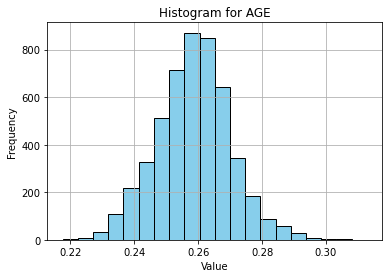

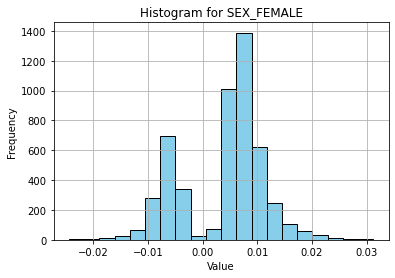

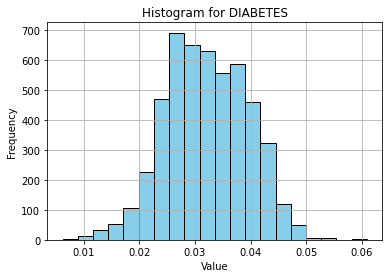

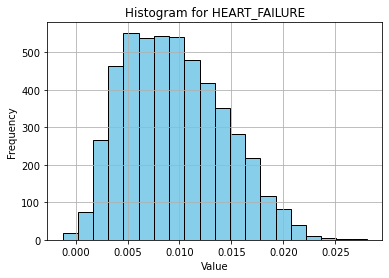

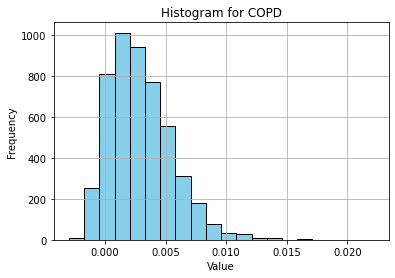

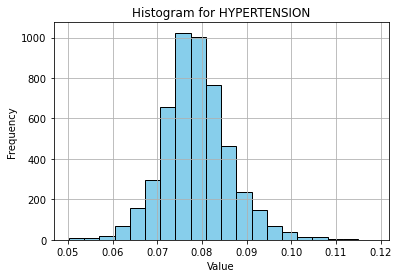

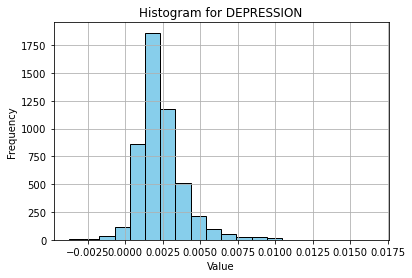

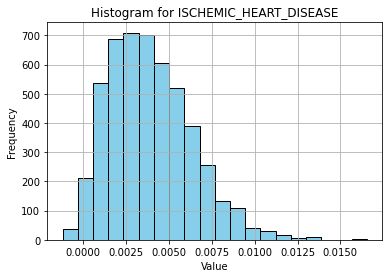

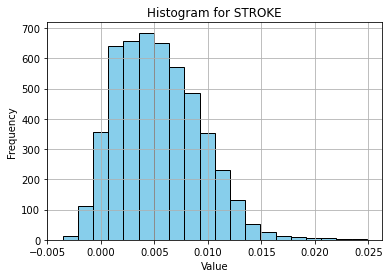

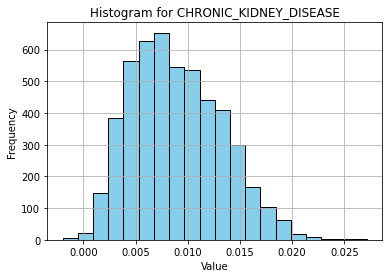

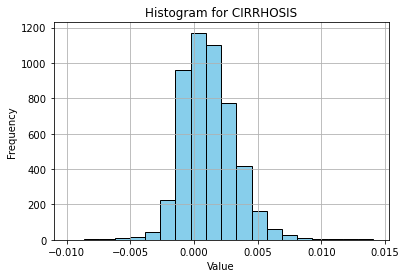

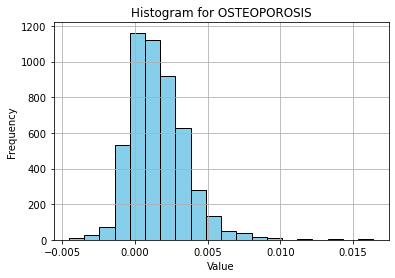

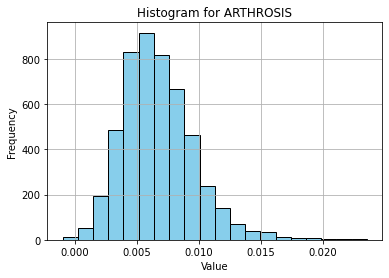

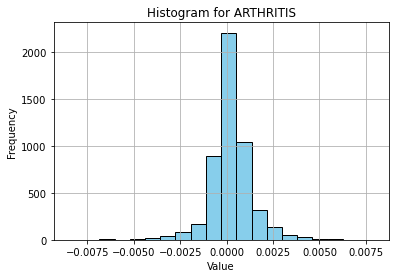

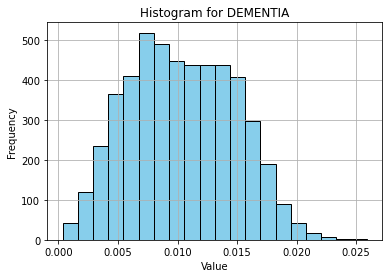

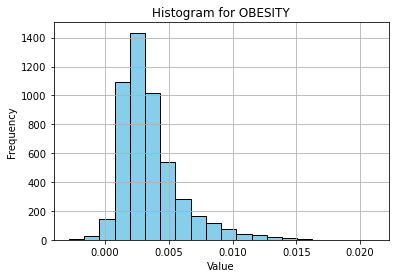

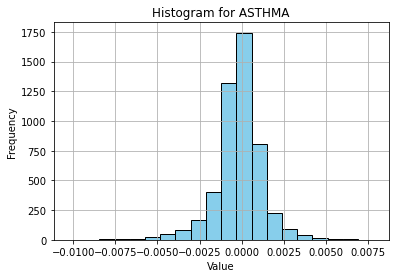

In [27]:
# Assuming 'shap_list_ir_1_subset_1' and 'featuresList' are already defined
df = maxDensityValues['feature']  # Access the DataFrame

# Define the folder to save histograms
output_folder = "maxDensity-histograms"
os.makedirs(output_folder, exist_ok=True)  # Create the folder if it doesn't exist

    # Create histograms for each feature
for feature in featuresList:
    plt.figure(figsize=(6, 4))  # Set figure size
    plt.hist(maxDensityValues[maxDensityValues['feature'] == feature]['freq1'], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram for {feature}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(True)
    
    # Save the histogram as a PNG file in the specified folder
    filename = os.path.join(output_folder, f"Histogram_for_{feature.replace(' ', '_')}.png")  # Replace spaces with underscores for filenames
    plt.savefig(filename, dpi=300, bbox_inches='tight')

***
***
## TEMP

In [38]:
# Function to replace feature names with corresponding freq1 values
def replace_features_with_freq(row, localMaxDict):
    subset_name = row['Subset']
    sorted_features = row['Sorted_Features']
    
    updated_sorted_features = []
    
    # Iterate through the feature names in the Sorted_Features list
    for feature in sorted_features:
        # Create a key to check in localMaxDict (using the subset and feature)
        key = (subset_name, feature)
        
        # Look up the freq1 value in localMaxDict based on the key
        if key in localMaxDict:
            updated_sorted_features.append(localMaxDict[key]['freq1'])  # Append the freq1 value
        else:
            updated_sorted_features.append(None)  # If no match is found, add None (or handle as needed)
    
    return updated_sorted_features

# Apply the function to the dataframe
sorted_orderScore['maxLocalOrder'] = sorted_orderScore.apply(replace_features_with_freq, axis=1, localMaxDict=localMaxDict)

# Display the updated dataframe with the new 'maxLocalOrder' column
print(sorted_orderScore[['Subset', 'Indicator', 'Sorted_Features', 'maxLocalOrder']])


                             Subset  Indicator  \
0       mlp_shap_list_ir_1_subset_4  orderMean   
1       mlp_shap_list_ir_1_subset_4   orderStd   
2       mlp_shap_list_ir_1_subset_4   orderSum   
3      mlp_shap_list_ir_2_subset_14  orderMean   
4      mlp_shap_list_ir_2_subset_14   orderStd   
...                             ...        ...   
2395    mlp_shap_list_ir_2_subset_8   orderStd   
2396    mlp_shap_list_ir_2_subset_8   orderSum   
2397  mlp_shap_list_ir_1_subset_112  orderMean   
2398  mlp_shap_list_ir_1_subset_112   orderStd   
2399  mlp_shap_list_ir_1_subset_112   orderSum   

                                        Sorted_Features  \
0     [Insulin, Glucose, SkinThickness, BloodPressur...   
1     [Insulin, Glucose, SkinThickness, BloodPressur...   
2     [Insulin, Glucose, SkinThickness, BloodPressur...   
3     [Glucose, Age, Insulin, Pregnancies, BMI, Bloo...   
4     [Age, Glucose, Pregnancies, SkinThickness, Blo...   
...                                          

In [42]:
aaa = sorted_orderScore.apply(replace_feature_with_freq, axis=1, localMaxDict=localMaxDict)

TypeError: replace_feature_with_freq() missing 1 required positional argument: 'subset'

In [ ]:
aaa

0      [ARTHRITIS, ASTHMA, CIRRHOSIS, DEPRESSION, OST...
1      [ARTHRITIS, ASTHMA, DEPRESSION, SEX_FEMALE, OB...
2      [AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D...
3      [ARTHRITIS, ASTHMA, OSTEOPOROSIS, CIRRHOSIS, O...
4      [ARTHRITIS, ASTHMA, OBESITY, DEPRESSION, SEX_F...
                             ...                        
100    [ARTHRITIS, ASTHMA, SEX_FEMALE, OBESITY, DEPRE...
101    [AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D...
102    [ARTHRITIS, ASTHMA, CIRRHOSIS, OBESITY, OSTEOP...
103    [ARTHRITIS, ASTHMA, SEX_FEMALE, OBESITY, DEPRE...
104    [AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D...
Length: 105, dtype: object

In [43]:
# Function to replace feature names with corresponding freq1 values from localMaxDict
def replace_feature_with_freq(row, localMaxDict):
    subset_name = row['Subset']
    indicator = row['Indicator']
    sorted_features = row['Sorted_Features']
    
    # Create the key based on Subset and Indicator
    key = (subset_name, f'localMax_{indicator}')  # Use 'localMax_' prefix to match the keys in localMaxDict
    
    # Initialize an empty list for storing the replaced values
    updated_sorted_features = []
    
    # Check if the combination of Subset and Indicator exists in localMaxDict
    if key in localMaxDict:
        # Get the mapping of features to freq1 for this key
        feature_to_freq1 = localMaxDict[key]
        
        # Iterate through the sorted_features list and replace feature with freq1 value if it matches
        for feature in sorted_features:
            # If feature matches the one in the dictionary, replace it with freq1
            if feature == feature_to_freq1['feature']:
                updated_sorted_features.append(feature_to_freq1['freq1'])
            else:
                updated_sorted_features.append(feature)
    else:
        # If key doesn't exist, just use the original Sorted_Features list
        updated_sorted_features = sorted_features
    
    return updated_sorted_features

# # Apply the function to the dataframe
# sorted_orderScore['localMaxOrder'] = sorted_orderScore.apply(replace_feature_with_freq, axis=1, localMaxDict=localMaxDict)

# # Display the updated dataframe
# print(sorted_orderScore[['Subset', 'Indicator', 'Sorted_Features', 'localMaxOrder']])


In [44]:
aaa = sorted_orderScore.apply(replace_feature_with_freq, axis=1, localMaxDict=localMaxDict)

In [45]:
aaa

0       [Insulin, Glucose, SkinThickness, BloodPressur...
1       [Insulin, Glucose, SkinThickness, BloodPressur...
2       [Insulin, Glucose, SkinThickness, BloodPressur...
3       [Glucose, Age, Insulin, Pregnancies, BMI, Bloo...
4       [Age, Glucose, Pregnancies, SkinThickness, Blo...
                              ...                        
2395    [Age, BloodPressure, Insulin, Glucose, SkinThi...
2396    [Insulin, Glucose, Age, BloodPressure, SkinThi...
2397    [Insulin, SkinThickness, Glucose, BloodPressur...
2398    [Glucose, Insulin, SkinThickness, BloodPressur...
2399    [Insulin, SkinThickness, Glucose, BloodPressur...
Length: 2400, dtype: object

In [46]:
aaa[0]

['Insulin',
 'Glucose',
 'SkinThickness',
 'BloodPressure',
 'BMI',
 'Pregnancies',
 'DiabetesPedigreeFunction',
 'Age']

In [47]:
# Function to replace feature names with corresponding freq1 values
def replace_features_with_freq(row):
    # Replace the feature names in "Sorted_Features" with the "freq1" value
    sorted_features = row['Sorted_Features']
    feature_list = row['feature']
    freq1 = row['freq1']
    
    # Replace feature names with corresponding freq1 value
    updated_sorted_features = [freq1 if feature == feature_name else feature_name 
                               for feature, feature_name in zip(sorted_features, feature_list)]
    
    return updated_sorted_features

# # Apply the function to the merged dataframe
# merged_df['Sorted_Features'] = merged_df.apply(replace_features_with_freq, axis=1)

# # Display the updated DataFrame
# print(merged_df)


In [48]:
# Function to replace the feature in Sorted_Features with corresponding freq1 value
def replace_feature_with_freq(row):
    sorted_features = row['Sorted_Features']  # List of features
    feature_name = row['feature']  # The feature to match
    freq1_value = row['freq1']  # The corresponding freq1 value
    
    # Replace the feature name in Sorted_Features with freq1_value if it matches the feature_name
    updated_sorted_features = [
        freq1_value if feature == feature_name else feature
        for feature in sorted_features
    ]
    
    return updated_sorted_features

# Apply the function to the merged dataframe
merged_df['Sorted_Features'] = merged_df.apply(replace_feature_with_freq, axis=1)

# Display the updated DataFrame
print(merged_df)


NameError: name 'merged_df' is not defined

In [49]:
distanceScore_df['ind_Features'] = distanceScore_df.apply(replace_features_with_freq, axis=1)

In [122]:
distDf = distanceScore_df.copy()
distDf['localMaxOrder'] = distanceScore_df.apply(replace_features_with_freq, axis=1)

TypeError: 'float' object is not iterable

In [120]:
distanceScore_df

,imbalanceRatio_x,Subset,Indicator_x,Sorted_Features,imbalanceRatio_y,feature,Indicator_y,freq1,freq2,freq3
0,shap_list_ir_1,shap_list_ir_1_subset_1,orderMean,"[ARTHRITIS, ASTHMA, CIRRHOSIS, DEPRESSION, OST...",shap_list_ir_1,AGE,localMax_AGE,0.246460,0.279899,0.213021
1,shap_list_ir_1,shap_list_ir_1_subset_1,orderMean,"[ARTHRITIS, ASTHMA, CIRRHOSIS, DEPRESSION, OST...",shap_list_ir_1,SEX_FEMALE,localMax_SEX_FEMALE,0.006367,-0.005332,0.008707
2,shap_list_ir_1,shap_list_ir_1_subset_1,orderMean,"[ARTHRITIS, ASTHMA, CIRRHOSIS, DEPRESSION, OST...",shap_list_ir_1,DIABETES,localMax_DIABETES,0.032392,-0.023365,0.088148
3,shap_list_ir_1,shap_list_ir_1_subset_1,orderMean,"[ARTHRITIS, ASTHMA, CIRRHOSIS, DEPRESSION, OST...",shap_list_ir_1,HEART_FAILURE,localMax_HEART_FAILURE,0.013885,-0.021374,-0.003744
4,shap_list_ir_1,shap_list_ir_1_subset_1,orderMean,"[ARTHRITIS, ASTHMA, CIRRHOSIS, DEPRESSION, OST...",shap_list_ir_1,COPD,localMax_COPD,-0.000027,-0.006628,0.006574
...,...,...,...,...,...,...,...,...,...,...
1780,shap_list_ir_5,shap_list_ir_5_subset_7,orderSum,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D...",shap_list_ir_5,ARTHROSIS,localMax_ARTHROSIS,0.004873,-0.001097,-0.007067
1781,shap_list_ir_5,shap_list_ir_5_subset_7,orderSum,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D...",shap_list_ir_5,ARTHRITIS,localMax_ARTHRITIS,0.000742,-0.001404,-0.003551
1782,shap_list_ir_5,shap_list_ir_5_subset_7,orderSum,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D...",shap_list_ir_5,DEMENTIA,localMax_DEMENTIA,0.015091,-0.010908,-0.002241
1783,shap_list_ir_5,shap_list_ir_5_subset_7,orderSum,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D...",shap_list_ir_5,OBESITY,localMax_OBESITY,0.002425,-0.001682,0.000372


In [119]:
distDf

,imbalanceRatio_x,Subset,Indicator_x,Sorted_Features,imbalanceRatio_y,feature,Indicator_y,freq1,freq2,freq3,localMaxOrder
0,shap_list_ir_1,shap_list_ir_1_subset_1,orderMean,"[ARTHRITIS, ASTHMA, CIRRHOSIS, DEPRESSION, OST...",shap_list_ir_1,AGE,localMax_AGE,0.246460,0.279899,0.213021,"[A, G, E]"
1,shap_list_ir_1,shap_list_ir_1_subset_1,orderMean,"[ARTHRITIS, ASTHMA, CIRRHOSIS, DEPRESSION, OST...",shap_list_ir_1,SEX_FEMALE,localMax_SEX_FEMALE,0.006367,-0.005332,0.008707,"[S, E, X, _, F, E, M, A, L, E]"
2,shap_list_ir_1,shap_list_ir_1_subset_1,orderMean,"[ARTHRITIS, ASTHMA, CIRRHOSIS, DEPRESSION, OST...",shap_list_ir_1,DIABETES,localMax_DIABETES,0.032392,-0.023365,0.088148,"[D, I, A, B, E, T, E, S]"
3,shap_list_ir_1,shap_list_ir_1_subset_1,orderMean,"[ARTHRITIS, ASTHMA, CIRRHOSIS, DEPRESSION, OST...",shap_list_ir_1,HEART_FAILURE,localMax_HEART_FAILURE,0.013885,-0.021374,-0.003744,"[H, E, A, R, T, _, F, A, I, L, U, R, E]"
4,shap_list_ir_1,shap_list_ir_1_subset_1,orderMean,"[ARTHRITIS, ASTHMA, CIRRHOSIS, DEPRESSION, OST...",shap_list_ir_1,COPD,localMax_COPD,-0.000027,-0.006628,0.006574,"[C, O, P, D]"
...,...,...,...,...,...,...,...,...,...,...,...
1780,shap_list_ir_5,shap_list_ir_5_subset_7,orderSum,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D...",shap_list_ir_5,ARTHROSIS,localMax_ARTHROSIS,0.004873,-0.001097,-0.007067,"[A, R, T, H, R, O, S, I, S]"
1781,shap_list_ir_5,shap_list_ir_5_subset_7,orderSum,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D...",shap_list_ir_5,ARTHRITIS,localMax_ARTHRITIS,0.000742,-0.001404,-0.003551,"[A, R, T, H, R, I, T, I, S]"
1782,shap_list_ir_5,shap_list_ir_5_subset_7,orderSum,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D...",shap_list_ir_5,DEMENTIA,localMax_DEMENTIA,0.015091,-0.010908,-0.002241,"[D, E, M, E, N, T, I, A]"
1783,shap_list_ir_5,shap_list_ir_5_subset_7,orderSum,"[AGE, HYPERTENSION, DIABETES, CHRONIC_KIDNEY_D...",shap_list_ir_5,OBESITY,localMax_OBESITY,0.002425,-0.001682,0.000372,"[O, B, E, S, I, T, Y]"
